In [1]:
!pip install nltk
!pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
data = pd.read_csv("train.txt", sep=";",header=None)
data.columns=["Text","Emotions"]
data

,Text,Emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [3]:
data.Emotions.unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [4]:
texts=data["Text"].tolist()
labels=data["Emotions"].tolist()

In [5]:
tokenizer=Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
word_index=tokenizer.word_index  #counts frequescy and returns dictionay
#word_index
len(tokenizer.word_index)

15213

In [6]:
sequences= tokenizer.texts_to_sequences(texts)
len_list=[len(x) for x in sequences]
padded=pad_sequences(sequences)
#len_list

In [7]:
max_length=padded.shape[1]

padded.shape

(16000, 66)

(array([  8.,  45., 310., 488., 539., 625., 626., 629., 613., 636., 654.,
        655., 608., 622., 609., 603., 559., 535., 530., 510., 452., 430.,
        382., 385., 330., 327., 336., 317., 238., 208., 200., 200., 167.,
        157., 141., 144., 120., 117., 117.,  88.,  96.,  72.,  66.,  66.,
         65.,  52.,  37.,  43.,  30.,  32.,  31.,  26.,  30.,  20.,  23.,
         14.,   9.,  10.,   4.,   4.,   4.,   1.,   4.,   1.]),
 array([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
        15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
        28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40.,
        41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53.,
        54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66.]),
 <BarContainer object of 64 artists>)

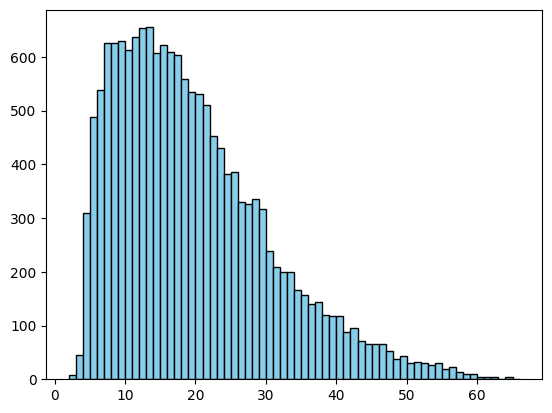

In [8]:
import matplotlib.pyplot as plt
plt.hist(len_list, bins=64, edgecolor='black', color='skyblue')

In [9]:
#Encoding string to label
label_encoder=LabelEncoder()
labels = label_encoder.fit_transform(labels)

In [10]:
labels

array([4, 4, 0, ..., 2, 0, 4], dtype=int64)

In [11]:
one_hot_labels = tf.keras.utils.to_categorical(labels)
one_hot_labels

array([[0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]], dtype=float32)

In [12]:
xtrain,xtest,ytrain,ytest=train_test_split(padded,one_hot_labels,test_size=0.2)

In [13]:
model=Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index)+1,output_dim=128,input_length=max_length))
model.add(Flatten())
model.add(Dense(units=128,activation="relu"))
model.add(Dense(units=len(one_hot_labels[0]),activation="softmax"))
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
model.fit(xtrain,ytrain,epochs=10,batch_size=32,validation_data=(xtest,ytest))

Epoch 1/10
400/400 [==============================] - 19s 43ms/step - loss: 1.3353 - accuracy: 0.4898 - val_loss: 0.9192 - val_accuracy: 0.6759
Epoch 2/10
400/400 [==============================] - 18s 44ms/step - loss: 0.3848 - accuracy: 0.8794 - val_loss: 0.5363 - val_accuracy: 0.8166
Epoch 3/10
400/400 [==============================] - 18s 45ms/step - loss: 0.0614 - accuracy: 0.9841 - val_loss: 0.5896 - val_accuracy: 0.8131
Epoch 4/10
400/400 [==============================] - 21s 53ms/step - loss: 0.0253 - accuracy: 0.9948 - val_loss: 0.6012 - val_accuracy: 0.8172
Epoch 5/10
400/400 [==============================] - 18s 45ms/step - loss: 0.0179 - accuracy: 0.9968 - val_loss: 0.6126 - val_accuracy: 0.8213
Epoch 6/10
400/400 [==============================] - 26s 65ms/step - loss: 0.0135 - accuracy: 0.9972 - val_loss: 0.6535 - val_accuracy: 0.8141
Epoch 7/10
400/400 [==============================] - 21s 51ms/step - loss: 0.0123 - accuracy: 0.9975 - val_loss: 0.6940 - val_accuracy:

In [16]:
input_text="im in hevan"
# Preprocess the input text
input_sequence = tokenizer.texts_to_sequences([input_text])
padded_input_sequence = pad_sequences(input_sequence, maxlen=max_length)
prediction = model.predict(padded_input_sequence)
predicted_label = label_encoder.inverse_transform([np.argmax(prediction[0])])
print(predicted_label[0])

1/1 [==============================] - 0s 60ms/step
sadness


In [170]:
#'sadness', 'anger', 'love', 'surprise', 'fear', 'joy'